<a href="https://colab.research.google.com/github/Pranshu244/Student-Risk-Detection-System/blob/main/ML_Pipeline_Code/Student_risk_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix,classification_report, accuracy_score, precision_score, recall_score,f1_score)
import pickle

In [2]:
df=pd.read_csv("Student_data.csv")

In [3]:
df.head()

,student_id,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,at_risk
0,104704,3.160583,13,0.680576,0.804794,25,87.881190,20.175614,6,12,0.160979,0
1,100982,1.926393,6,0.824740,0.671424,25,74.207038,28.650467,6,13,0.164562,0
2,101115,3.820345,12,0.931174,0.735689,17,73.882449,21.271747,5,5,0.366379,0
3,104222,5.091741,8,0.868599,0.763398,15,83.362701,86.731620,6,3,0.399749,0
4,102654,4.570271,8,0.764270,0.813890,20,57.065443,40.572608,1,6,0.137774,0


In [4]:
df.tail()

,student_id,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,at_risk
6795,103772,2.875831,10,0.963922,0.830361,5,68.755989,27.751066,2,12,0.230249,0
6796,105191,4.303234,10,0.752047,0.793522,13,73.853510,44.284858,5,3,0.346928,0
6797,105226,3.833229,12,0.754852,0.651409,5,55.028512,77.338357,6,6,0.335996,0
6798,105390,2.057801,11,0.874326,0.786516,17,66.334165,23.492905,5,1,0.134377,0
6799,100860,4.602110,8,0.854350,0.852695,24,83.024922,88.834683,3,11,0.300061,0


In [5]:
df.shape

(6800, 12)

In [6]:
df.describe()

,student_id,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,at_risk
count,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000
mean,103399.500000,3.229563,9.349265,0.747441,0.771246,13.887500,68.002527,50.634446,4.512941,7.326324,0.298793,0.088235
std,1963.135248,1.382187,4.688934,0.205490,0.197285,6.913124,17.516524,23.589539,5.528794,4.612741,0.180006,0.283658
min,100000.000000,0.001354,0.000000,0.000523,0.002510,0.000000,0.000379,2.012339,0.000000,0.000000,0.100031,0.000000
25%,101699.750000,2.178678,6.000000,0.673366,0.711927,8.000000,61.250160,32.240153,1.000000,3.000000,0.182365,0.000000
50%,103399.500000,3.282119,9.000000,0.779388,0.804199,14.000000,70.567543,51.478814,3.000000,7.000000,0.266126,0.000000
75%,105099.250000,4.380856,12.000000,0.888181,0.902424,20.000000,80.080339,70.732345,5.000000,11.000000,0.346449,0.000000
max,106799.000000,5.498871,30.000000,0.999957,0.999893,25.000000,89.992628,89.948808,30.000000,15.000000,0.999976,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   student_id                    6800 non-null   int64  
 1   avg_daily_study_hours         6800 non-null   float64
 2   login_frequency_per_week      6800 non-null   int64  
 3   course_completion_rate        6800 non-null   float64
 4   assignment_submission_rate    6800 non-null   float64
 5   videos_watched_per_week       6800 non-null   int64  
 6   avg_quiz_score                6800 non-null   float64
 7   avg_session_duration_minutes  6800 non-null   float64
 8   inactive_days_last_30         6800 non-null   int64  
 9   forum_participation_count     6800 non-null   int64  
 10  content_rewatch_rate          6800 non-null   float64
 11  at_risk                       6800 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 637.6 KB


In [8]:
df.isnull().sum()

,0
student_id,0
avg_daily_study_hours,0
login_frequency_per_week,0
course_completion_rate,0
assignment_submission_rate,0
videos_watched_per_week,0
avg_quiz_score,0
avg_session_duration_minutes,0
inactive_days_last_30,0
forum_participation_count,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df_r= df.drop(columns=['student_id','at_risk'])

In [11]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_daily_study_hours         6800 non-null   float64
 1   login_frequency_per_week      6800 non-null   int64  
 2   course_completion_rate        6800 non-null   float64
 3   assignment_submission_rate    6800 non-null   float64
 4   videos_watched_per_week       6800 non-null   int64  
 5   avg_quiz_score                6800 non-null   float64
 6   avg_session_duration_minutes  6800 non-null   float64
 7   inactive_days_last_30         6800 non-null   int64  
 8   forum_participation_count     6800 non-null   int64  
 9   content_rewatch_rate          6800 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 531.4 KB


In [12]:
df_r.shape

(6800, 10)

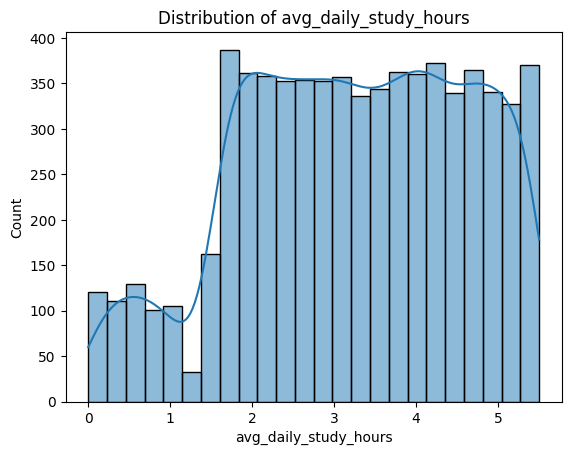

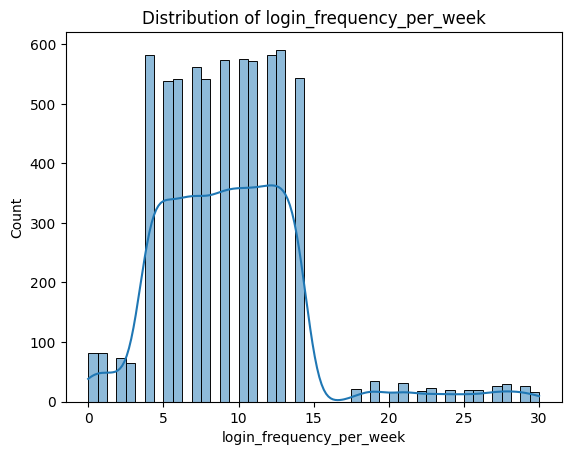

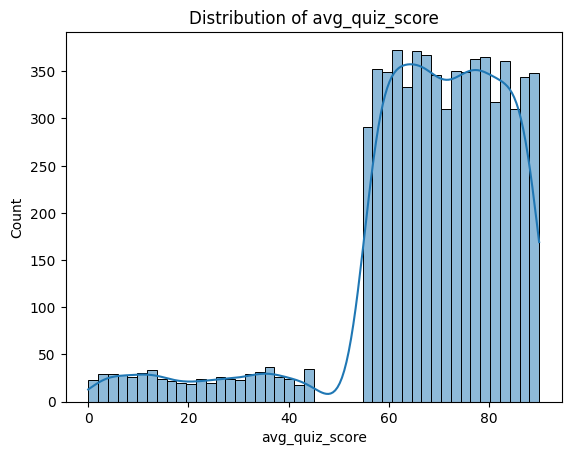

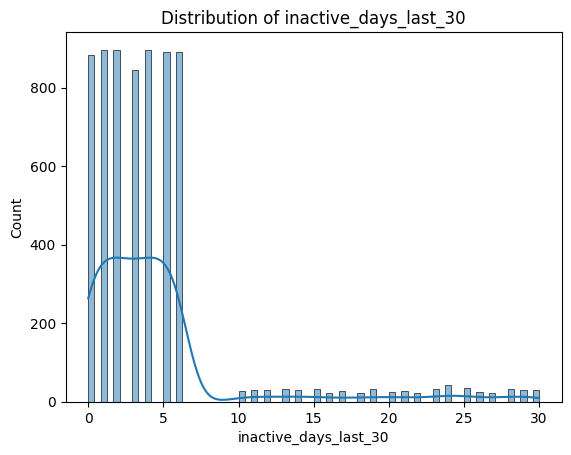

In [13]:
cols = ['avg_daily_study_hours','login_frequency_per_week','avg_quiz_score','inactive_days_last_30']
for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

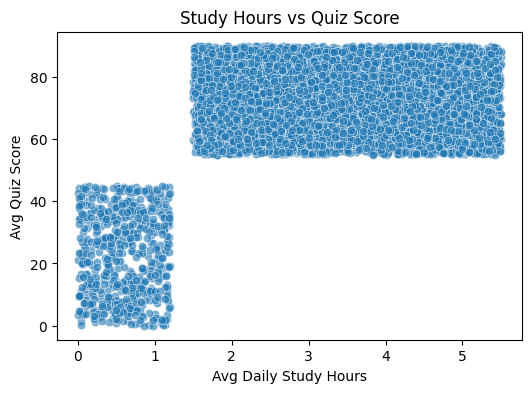

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot( x=df['avg_daily_study_hours'],y=df['avg_quiz_score'],alpha=0.6)
plt.title('Study Hours vs Quiz Score')
plt.xlabel('Avg Daily Study Hours')
plt.ylabel('Avg Quiz Score')
plt.show()

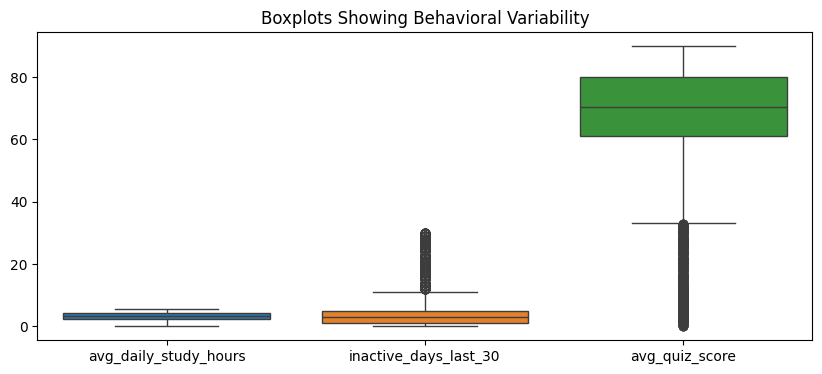

In [15]:
box_cols = ['avg_daily_study_hours', 'inactive_days_last_30', 'avg_quiz_score']
plt.figure(figsize=(10,4))
sns.boxplot(data=df[box_cols])
plt.title('Boxplots Showing Behavioral Variability')
plt.show()

In [16]:
data_scaler=StandardScaler()
x_scaled=data_scaler.fit_transform(df_r)

In [17]:
iso = IsolationForest(n_estimators=200,contamination=0.08,random_state=42)
iso_pred=iso.fit_predict(x_scaled)
iso_flag=(iso_pred==-1).astype(int)
df_r['iso_flag']=iso_flag
df_r['iso_score']=iso.decision_function(x_scaled)

In [18]:
df_r['iso_flag'].value_counts()

,count
iso_flag,
0,6256
1,544


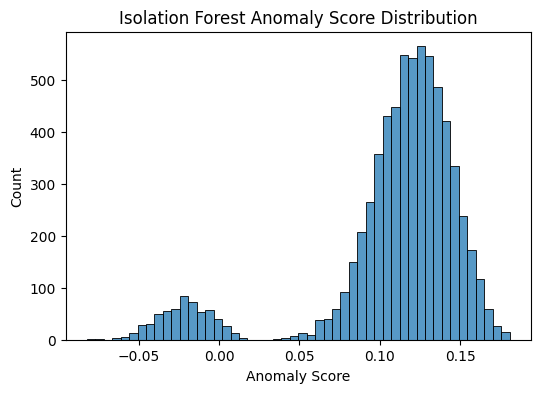

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df_r['iso_score'], bins=50)
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42,n_init=10)
cluster_labels = kmeans.fit_predict(x_scaled)
df_r['cluster_id'] = cluster_labels

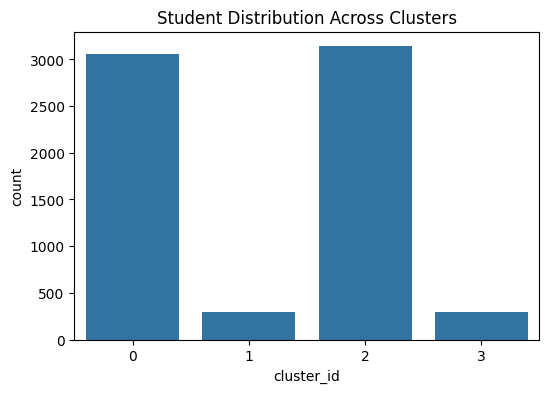

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_r['cluster_id'])
plt.title('Student Distribution Across Clusters')
plt.show()

In [22]:
df_r.head()

,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,iso_flag,iso_score,cluster_id
0,3.160583,13,0.680576,0.804794,25,87.881190,20.175614,6,12,0.160979,0,0.068244,0
1,1.926393,6,0.824740,0.671424,25,74.207038,28.650467,6,13,0.164562,0,0.084958,0
2,3.820345,12,0.931174,0.735689,17,73.882449,21.271747,5,5,0.366379,0,0.120309,2
3,5.091741,8,0.868599,0.763398,15,83.362701,86.731620,6,3,0.399749,0,0.088100,2
4,4.570271,8,0.764270,0.813890,20,57.065443,40.572608,1,6,0.137774,0,0.140981,2


In [23]:
df_r.groupby('cluster_id').mean()[['avg_daily_study_hours','login_frequency_per_week','avg_quiz_score','inactive_days_last_30']]

,avg_daily_study_hours,login_frequency_per_week,avg_quiz_score,inactive_days_last_30
cluster_id,,,,
0,3.488304,9.098039,72.421427,2.974510
1,0.581090,1.396667,22.792469,20.200000
2,3.482345,8.966242,72.360979,3.029618
3,0.593080,23.873333,22.521339,20.043333


In [24]:
df_r.groupby('cluster_id')['iso_flag'].mean()

,iso_flag
cluster_id,
0,0.000000
1,0.860000
2,0.000000
3,0.953333


In [25]:
x_train_ae = x_scaled[df_r['iso_flag'] == 0]

In [26]:
input_dim = x_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(4, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam',loss='mse')

In [27]:
history = autoencoder.fit(x_train_ae,x_train_ae,epochs=25,batch_size=32,shuffle=True,verbose=1)

Epoch 1/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5038
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3867
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3165
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2881
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2730
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2635
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2581
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2546
Epoch 9/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2523
Epoch 10/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2507
Epoch 11/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2494
Epoch 12/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2373
Epoch 13/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2146
Epoch 14/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1991
Epoch 15/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [28]:
X_reconstructed = autoencoder.predict(x_scaled)
reconstruction_error = np.mean(np.square(x_scaled - X_reconstructed),axis=1)
df_r['ae_error']=reconstruction_error

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
df_r.head()

,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,iso_flag,iso_score,cluster_id,ae_error
0,3.160583,13,0.680576,0.804794,25,87.881190,20.175614,6,12,0.160979,0,0.068244,0,0.227557
1,1.926393,6,0.824740,0.671424,25,74.207038,28.650467,6,13,0.164562,0,0.084958,0,0.188626
2,3.820345,12,0.931174,0.735689,17,73.882449,21.271747,5,5,0.366379,0,0.120309,2,0.149790
3,5.091741,8,0.868599,0.763398,15,83.362701,86.731620,6,3,0.399749,0,0.088100,2,0.166127
4,4.570271,8,0.764270,0.813890,20,57.065443,40.572608,1,6,0.137774,0,0.140981,2,0.141802


In [30]:
ae_threshold = np.percentile(df_r['ae_error'], 92)
df_r['ae_flag'] = (df_r['ae_error'] > ae_threshold).astype(int)

In [31]:
df_r['ae_flag'].value_counts()

,count
ae_flag,
0,6256
1,544


In [32]:
pd.crosstab(df_r['iso_flag'], df_r['ae_flag'])

ae_flag,0,1
iso_flag,,
0,6163,93
1,93,451


In [33]:
cluster_risk = {0: 0,  1: 1,  2: 0,  3: 1}
df_r['cluster_risk'] = df_r['cluster_id'].map(cluster_risk)

In [34]:
scaler = MinMaxScaler()
df_r['iso_score_norm'] = scaler.fit_transform(df_r[['iso_score']])
df_r['ae_error_norm'] = scaler.fit_transform(df_r[['ae_error']])

In [35]:
df_r['final_risk_score'] = (0.4 * df_r['cluster_risk'] +0.3 * df_r['iso_flag'] +0.3 * df_r['ae_flag'])
df_r['final_at_risk'] = (df_r['final_risk_score'] >= 0.7).astype(int)

In [36]:
df_r.head()

,avg_daily_study_hours,login_frequency_per_week,course_completion_rate,assignment_submission_rate,videos_watched_per_week,avg_quiz_score,avg_session_duration_minutes,inactive_days_last_30,forum_participation_count,content_rewatch_rate,iso_flag,iso_score,cluster_id,ae_error,ae_flag,cluster_risk,iso_score_norm,ae_error_norm,final_risk_score,final_at_risk
0,3.160583,13,0.680576,0.804794,25,87.881190,20.175614,6,12,0.160979,0,0.068244,0,0.227557,0,0,0.572534,0.088064,0.0,0
1,1.926393,6,0.824740,0.671424,25,74.207038,28.650467,6,13,0.164562,0,0.084958,0,0.188626,0,0,0.636093,0.071982,0.0,0
2,3.820345,12,0.931174,0.735689,17,73.882449,21.271747,5,5,0.366379,0,0.120309,2,0.149790,0,0,0.770519,0.055940,0.0,0
3,5.091741,8,0.868599,0.763398,15,83.362701,86.731620,6,3,0.399749,0,0.088100,2,0.166127,0,0,0.648041,0.062688,0.0,0
4,4.570271,8,0.764270,0.813890,20,57.065443,40.572608,1,6,0.137774,0,0.140981,2,0.141802,0,0,0.849127,0.052640,0.0,0


In [37]:
pd.crosstab(df_r['final_at_risk'], df['at_risk'],rownames=['Predicted'], colnames=['Actual'])

Actual,0,1
Predicted,,
0,6200,37
1,0,563


In [38]:
y_true = df['at_risk']
y_pred = df_r['final_at_risk']
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Confusion Matrix:
 [[6200    0]
 [  37  563]]

Accuracy  : 0.9946
Precision : 1.0000
Recall    : 0.9383
F1 Score  : 0.9682

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      6200
           1       1.00      0.94      0.97       600

    accuracy                           0.99      6800
   macro avg       1.00      0.97      0.98      6800
weighted avg       0.99      0.99      0.99      6800



In [39]:
cluster_risk_map = (df_r.groupby('cluster_id')['iso_flag'].mean().to_dict())

In [40]:
with open("model.pkl", "wb") as f:
    pickle.dump(( data_scaler, iso,kmeans,cluster_risk_map, ae_threshold,),f)

autoencoder.save("autoencoder.keras")